# NB01: Data Integration

Build a master annotation table joining AI agent annotations (GPT-5.2 + InterProScan) with RAST and Bakta annotations, plus all experimental data from the ADP1 explorer database.

**Key outputs:**
- Master table with all annotation sources and experimental columns
- Annotation coverage comparison across sources
- `data/master_annotation_table.csv`

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if 'adp1_annotation_reassessment' not in PROJECT_DIR:
    PROJECT_DIR = 'projects/adp1_annotation_reassessment'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

## Load Agent Annotations

In [2]:
agent_df = pd.read_csv(
    os.path.join(PROJECT_DIR, 'user_data/berdl-annotations.with-ipr.annotation_by_gene_detailed_dec_11_2025.tsv'),
    sep='\t'
)
print(f'Agent annotations: {len(agent_df)} sequences')
print(f'Columns: {list(agent_df.columns)}')
print(f'\nAnnotation sample:')
agent_df[['sequence', 'annotation']].head(3)

Agent annotations: 3083 sequences
Columns: ['sequence', 'genome_ids', 'model', 'annotation', 'evidence', 'reasoning', 'input_tokens', 'output_tokens', 'total_tokens', 'reasoning_tokens']

Annotation sample:


,sequence,annotation
0,MAAEEHALTSTEYIKHHLTNLTYGKMPDGTWKLAENAKEAQEMGFS...,Integral membrane subunit a (AtpB) of the F0 s...
1,MAAFNVERITHVHHWNDTLFSFKTTRDVALRFKNGQFVMIGLEVNG...,Predicted ferredoxin/flavodoxin–NADP(H) reduct...
2,MAAKKTQVMPVFAYEGVDRKGIKLKGELPARNMALAKVTLRKQGIT...,Putative GspF/PilC family inner-membrane platf...


## Load Genome Features from SQLite

In [3]:
conn = sqlite3.connect(os.path.join(PROJECT_DIR, 'user_data/berdl_tables.db'))

gf = pd.read_sql('SELECT * FROM genome_features', conn)
print(f'Genome features: {len(gf)} rows')
print(f'Columns: {list(gf.columns)}')

Genome features: 5852 rows
Columns: ['id', 'genome_id', 'contig_id', 'feature_id', 'length', 'start', 'end', 'strand', 'sequence', 'sequence_hash', 'bakta_function', 'rast_function', 'cog', 'ec', 'gene_names', 'go', 'ko', 'pfam', 'so', 'uniref_100', 'uniref_90', 'uniref_50', 'pangenome_cluster_id', 'pangenome_is_core', 'psortb', 'reactions', 'rich_media_flux', 'rich_media_class', 'minimal_media_flux', 'minimal_media_class', 'rast_consistency', 'other_rast_annotations', 'essentiality_minimal', 'essentiality_lb', 'proteomics_avg_ADP1', 'proteomics_avg_ACN2821', 'proteomics_avg_ACN3430', 'proteomics_avg_ACN3425', 'proteomics_avg_ACN2586', 'proteomics_avg_ACN3429', 'proteomics_avg_ACN3427', 'proteomics_gene_id', 'mutant_growth_acetate', 'mutant_growth_asparagine', 'mutant_growth_butanediol', 'mutant_growth_glucarate', 'mutant_growth_glucose', 'mutant_growth_lactate', 'mutant_growth_quinate', 'mutant_growth_urea', 'old_locus_tag']


## Join Agent Annotations to Genome Features by Sequence

The agent file has protein sequences that should match the `sequence` column in `genome_features`.

In [4]:
# Some sequences appear in multiple genome_features rows (duplicates from multiple genomes)
# and some agent sequences map to multiple features. Let's check.
print(f'Unique sequences in agent: {agent_df["sequence"].nunique()}')
print(f'Unique sequences in genome_features: {gf["sequence"].nunique()}')

# Check overlap
agent_seqs = set(agent_df['sequence'])
gf_seqs = set(gf['sequence'].dropna())
overlap = agent_seqs & gf_seqs
print(f'\nOverlap: {len(overlap)} sequences')
print(f'Agent-only: {len(agent_seqs - gf_seqs)}')
print(f'GF-only: {len(gf_seqs - agent_seqs)}')

Unique sequences in agent: 3083
Unique sequences in genome_features: 3197

Overlap: 3083 sequences
Agent-only: 0
GF-only: 114


In [5]:
# Some agent sequences may be duplicated (same protein in multiple genome contexts)
# Keep unique agent annotations per sequence
agent_unique = agent_df.drop_duplicates(subset='sequence')[['sequence', 'annotation', 'evidence', 'reasoning']]
agent_unique = agent_unique.rename(columns={'annotation': 'agent_annotation', 'evidence': 'agent_evidence', 'reasoning': 'agent_reasoning'})
print(f'Unique agent annotations: {len(agent_unique)}')

Unique agent annotations: 3083


In [6]:
# Join: genome_features LEFT JOIN agent annotations on sequence
master = gf.merge(agent_unique, on='sequence', how='left')
print(f'Master table: {len(master)} rows')
print(f'With agent annotation: {master["agent_annotation"].notna().sum()}')
print(f'Without agent annotation: {master["agent_annotation"].isna().sum()}')

Master table: 5852 rows
With agent annotation: 3003
Without agent annotation: 2849


## Classify Annotations: Specific / Hypothetical / Missing

For each annotation source, classify as:
- **specific**: a meaningful functional annotation
- **hypothetical**: annotated as hypothetical/uncharacterized/unknown/DUF-only
- **missing**: no annotation provided

In [7]:
HYPOTHETICAL_PATTERNS = [
    r'^hypothetical\s+protein',
    r'^uncharacterized\s+protein',
    r'^putative\s+uncharacterized',
    r'^unknown\s+function',
    r'^protein\s+of\s+unknown\s+function',
    r'^DUF\d+',
    r'^Domain\s+of\s+unknown\s+function',
    r'^conserved\s+hypothetical',
    r'^predicted\s+protein',
    r'^membrane\s+protein$',  # bare "membrane protein" without specifics
]
HYPO_RE = re.compile('|'.join(HYPOTHETICAL_PATTERNS), re.IGNORECASE)

def classify_annotation(ann):
    """Classify an annotation string as specific, hypothetical, or missing."""
    if pd.isna(ann) or str(ann).strip() == '':
        return 'missing'
    ann_str = str(ann).strip()
    if HYPO_RE.search(ann_str):
        return 'hypothetical'
    return 'specific'

# Test
assert classify_annotation('hypothetical protein') == 'hypothetical'
assert classify_annotation('ATP synthase subunit a') == 'specific'
assert classify_annotation(None) == 'missing'
assert classify_annotation('DUF1234 domain-containing protein') == 'hypothetical'

master['rast_class'] = master['rast_function'].apply(classify_annotation)
master['bakta_class'] = master['bakta_function'].apply(classify_annotation)
master['agent_class'] = master['agent_annotation'].apply(classify_annotation)

print('RAST classification:')
print(master['rast_class'].value_counts())
print('\nBakta classification:')
print(master['bakta_class'].value_counts())
print('\nAgent classification:')
print(master['agent_class'].value_counts())

RAST classification:
rast_class
specific        2803
missing         2617
hypothetical     432
Name: count, dtype: int64

Bakta classification:
bakta_class
specific        2939
missing         2643
hypothetical     270
Name: count, dtype: int64

Agent classification:
agent_class
specific        2984
missing         2849
hypothetical      19
Name: count, dtype: int64


## Coverage Comparison

Source  Specific  Hypothetical  Missing  Coverage (%)
  RAST      2803           432     2617          47.9
 Bakta      2939           270     2643          50.2
 Agent      2984            19     2849          51.0


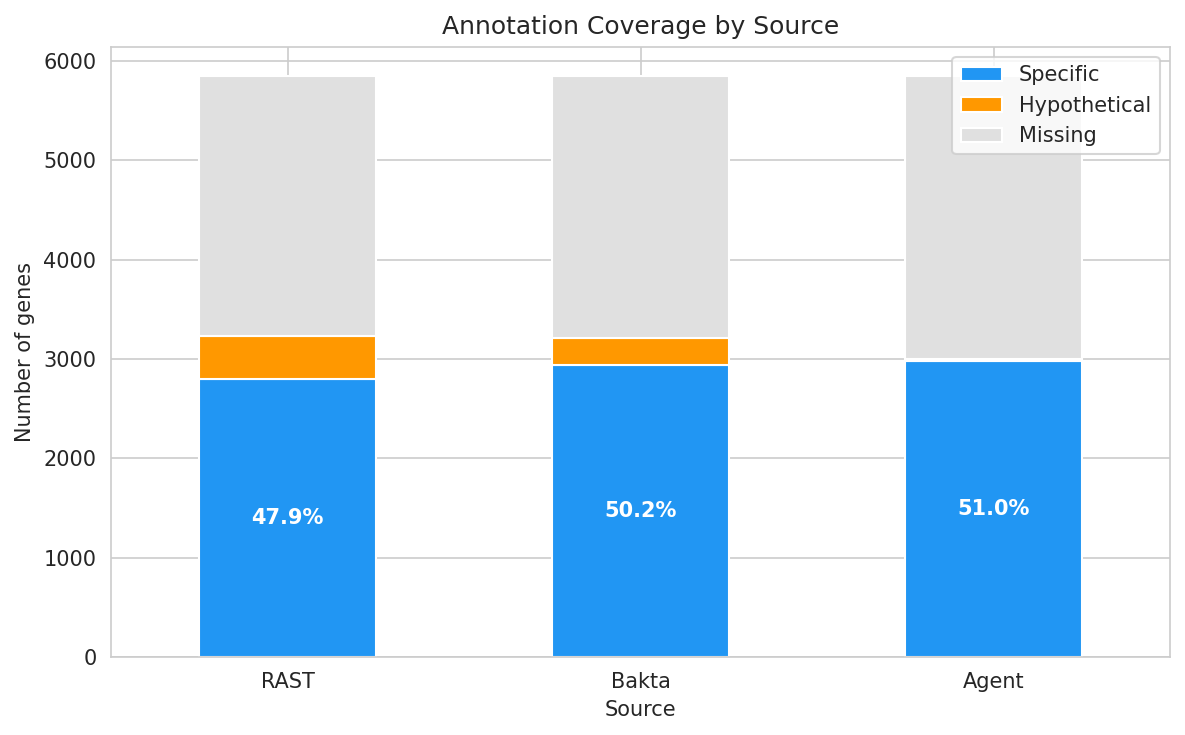


Agent annotation breakdown: 2984 specific + 19 hypothetical = 3003 total


In [8]:
# Coverage = fraction of genes with a specific (non-hypothetical, non-missing) annotation
coverage = pd.DataFrame({
    'Source': ['RAST', 'Bakta', 'Agent'],
    'Specific': [
        (master['rast_class'] == 'specific').sum(),
        (master['bakta_class'] == 'specific').sum(),
        (master['agent_class'] == 'specific').sum(),
    ],
    'Hypothetical': [
        (master['rast_class'] == 'hypothetical').sum(),
        (master['bakta_class'] == 'hypothetical').sum(),
        (master['agent_class'] == 'hypothetical').sum(),
    ],
    'Missing': [
        (master['rast_class'] == 'missing').sum(),
        (master['bakta_class'] == 'missing').sum(),
        (master['agent_class'] == 'missing').sum(),
    ]
})
coverage['Coverage (%)'] = (coverage['Specific'] / len(master) * 100).round(1)
print(coverage.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
coverage_plot = coverage.set_index('Source')[['Specific', 'Hypothetical', 'Missing']]
coverage_plot.plot(kind='bar', stacked=True, ax=ax, color=['#2196F3', '#FF9800', '#E0E0E0'])
ax.set_ylabel('Number of genes')
ax.set_title('Annotation Coverage by Source')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, (_, row) in enumerate(coverage.iterrows()):
    ax.text(i, row['Specific'] / 2, f"{row['Coverage (%)']:.1f}%", ha='center', va='center', fontweight='bold', color='white')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/annotation_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

# Clarification: "With agent annotation" count from the join (cell above) includes
# hypothetical annotations. Breakdown: 2,984 specific + 19 hypothetical = 3,003 total.
n_agent_total = master['agent_annotation'].notna().sum()
n_agent_spec = (master['agent_class'] == 'specific').sum()
n_agent_hypo = (master['agent_class'] == 'hypothetical').sum()
print(f'\nAgent annotation breakdown: {n_agent_spec} specific + {n_agent_hypo} hypothetical = {n_agent_total} total')

## Protein-Coding-Only Coverage

The agent only annotates protein-coding genes, so coverage comparisons using the 5,852 total features (including tRNA, rRNA, etc.) as denominator understate true coverage. Here we show coverage among protein-coding genes only.

Protein-coding genes: 3209 (of 5852 total features)
Non-coding features (tRNA, rRNA, etc.): 2643

Protein-coding coverage:
Source  Specific  Hypothetical  Missing  Coverage (%)
  RAST      2784           425        0          86.8
 Bakta      2939           270        0          91.6
 Agent      2984            19      206          93.0


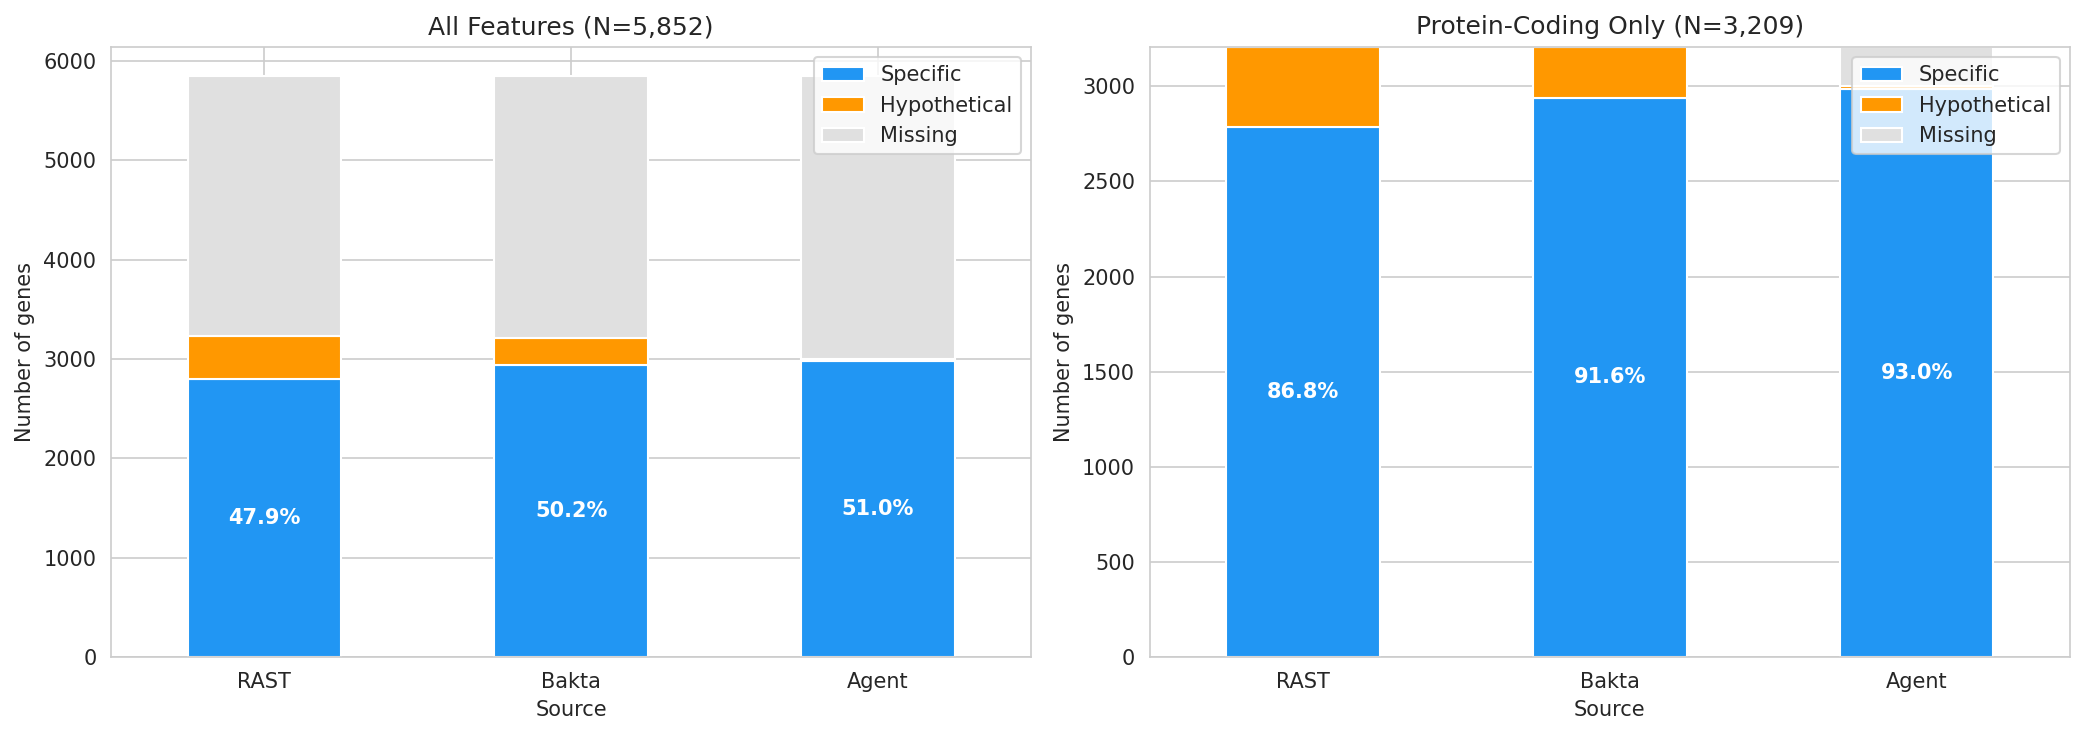


Key insight: Among protein-coding genes, agent covers 93.0%
vs RAST 86.8%
vs Bakta 91.6%


In [9]:
# Protein-coding = features with a protein sequence
protein_coding = master[master['sequence'].notna()].copy()
n_pc = len(protein_coding)
print(f'Protein-coding genes: {n_pc} (of {len(master)} total features)')
print(f'Non-coding features (tRNA, rRNA, etc.): {len(master) - n_pc}\n')

pc_coverage = pd.DataFrame({
    'Source': ['RAST', 'Bakta', 'Agent'],
    'Specific': [
        (protein_coding['rast_class'] == 'specific').sum(),
        (protein_coding['bakta_class'] == 'specific').sum(),
        (protein_coding['agent_class'] == 'specific').sum(),
    ],
    'Hypothetical': [
        (protein_coding['rast_class'] == 'hypothetical').sum(),
        (protein_coding['bakta_class'] == 'hypothetical').sum(),
        (protein_coding['agent_class'] == 'hypothetical').sum(),
    ],
    'Missing': [
        (protein_coding['rast_class'] == 'missing').sum(),
        (protein_coding['bakta_class'] == 'missing').sum(),
        (protein_coding['agent_class'] == 'missing').sum(),
    ]
})
pc_coverage['Coverage (%)'] = (pc_coverage['Specific'] / n_pc * 100).round(1)
print('Protein-coding coverage:')
print(pc_coverage.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all features (original)
coverage_plot = coverage.set_index('Source')[['Specific', 'Hypothetical', 'Missing']]
coverage_plot.plot(kind='bar', stacked=True, ax=axes[0], color=['#2196F3', '#FF9800', '#E0E0E0'])
axes[0].set_ylabel('Number of genes')
axes[0].set_title(f'All Features (N={len(master):,})')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, (_, row) in enumerate(coverage.iterrows()):
    axes[0].text(i, row['Specific'] / 2, f"{row['Coverage (%)']:.1f}%", ha='center', va='center',
                 fontweight='bold', color='white')
axes[0].legend(loc='upper right')

# Right: protein-coding only
pc_plot = pc_coverage.set_index('Source')[['Specific', 'Hypothetical', 'Missing']]
pc_plot.plot(kind='bar', stacked=True, ax=axes[1], color=['#2196F3', '#FF9800', '#E0E0E0'])
axes[1].set_ylabel('Number of genes')
axes[1].set_title(f'Protein-Coding Only (N={n_pc:,})')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, (_, row) in enumerate(pc_coverage.iterrows()):
    axes[1].text(i, row['Specific'] / 2, f"{row['Coverage (%)']:.1f}%", ha='center', va='center',
                 fontweight='bold', color='white')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/annotation_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nKey insight: Among protein-coding genes, agent covers {pc_coverage.loc[pc_coverage["Source"]=="Agent", "Coverage (%)"].values[0]}%')
print(f'vs RAST {pc_coverage.loc[pc_coverage["Source"]=="RAST", "Coverage (%)"].values[0]}%')
print(f'vs Bakta {pc_coverage.loc[pc_coverage["Source"]=="Bakta", "Coverage (%)"].values[0]}%')

## Save Master Table

In [10]:
# Select key columns for the master table
master_cols = [
    'feature_id', 'old_locus_tag', 'gene_names', 'contig_id', 'start', 'end', 'strand', 'length',
    'rast_function', 'bakta_function', 'agent_annotation',
    'rast_class', 'bakta_class', 'agent_class',
    'agent_evidence', 'agent_reasoning',
    'cog', 'ec', 'ko', 'pfam', 'go', 'so',
    'uniref_100', 'uniref_90', 'uniref_50',
    'pangenome_cluster_id', 'pangenome_is_core',
    'essentiality_minimal', 'essentiality_lb',
    'rich_media_flux', 'rich_media_class', 'minimal_media_flux', 'minimal_media_class',
    'mutant_growth_acetate', 'mutant_growth_asparagine', 'mutant_growth_butanediol',
    'mutant_growth_glucarate', 'mutant_growth_glucose', 'mutant_growth_lactate',
    'mutant_growth_quinate', 'mutant_growth_urea',
    'proteomics_avg_ADP1',
    'psortb', 'reactions',
    'sequence'
]

# Only include columns that exist
master_cols = [c for c in master_cols if c in master.columns]
master_out = master[master_cols].copy()

out_path = os.path.join(PROJECT_DIR, 'data/master_annotation_table.csv')
master_out.to_csv(out_path, index=False)
print(f'Saved master table: {len(master_out)} rows × {len(master_out.columns)} columns')
print(f'File: {out_path}')

Saved master table: 5852 rows × 45 columns
File: /home/psdehal/pangenome_science/BERIL-research-observatory/projects/adp1_annotation_reassessment/data/master_annotation_table.csv


In [11]:
# Summary statistics
has_growth = master_out[[c for c in master_out.columns if c.startswith('mutant_growth_')]].notna().any(axis=1).sum()
has_essentiality = master_out['essentiality_minimal'].notna().sum()
has_fba = master_out['minimal_media_class'].notna().sum()
has_proteomics = master_out['proteomics_avg_ADP1'].notna().sum()

print('Master table summary:')
print(f'  Total genes: {len(master_out)}')
print(f'  With growth data: {has_growth}')
print(f'  With essentiality: {has_essentiality}')
print(f'  With FBA flux: {has_fba}')
print(f'  With proteomics: {has_proteomics}')
print(f'  With agent annotation: {(master_out["agent_class"] == "specific").sum()}')

conn.close()

Master table summary:
  Total genes: 5852
  With growth data: 2350
  With essentiality: 3405
  With FBA flux: 866
  With proteomics: 2383
  With agent annotation: 2984
